In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [19]:
import os
cwd = os.getcwd()
parent = os.path.dirname(cwd)

Df = pd.read_csv(os.path.join(parent, 'train.csv'))
Df.index = Df['id'].values
Df.drop('id', axis=1, inplace=True)
Df.drop('market', axis=1, inplace=True)
Df.head()

,target,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,convective_inhibition,wind_speed_80m,wind_direction_80m,wind_gust_speed_10m,wind_speed_10m,solar_forecast,wind_forecast,load_forecast,delivery_start,delivery_end
0,-1.913,0.0,0.0,0.0,2.0,0.0,0.0,2.0,0.0,54100.0,...,0.0,31.253719,245.501450,25.199999,15.077082,0.0,24050.1,38163.01,2023-01-01 00:00:00,2023-01-01 01:00:00
1,-2.210,0.0,0.0,0.0,47.0,0.0,0.0,47.0,0.0,33700.0,...,0.0,40.258881,238.157578,30.239998,14.982228,0.0,24050.1,38163.01,2023-01-01 00:00:00,2023-01-01 01:00:00
2,-2.200,0.0,0.0,0.0,21.0,21.0,0.0,0.0,0.0,13200.0,...,0.0,28.585449,163.162445,24.119999,8.435069,0.0,24050.1,38163.01,2023-01-01 00:00:00,2023-01-01 01:00:00
3,-2.058,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16300.0,...,0.0,37.952263,141.934296,33.119999,18.584509,0.0,24050.1,38163.01,2023-01-01 00:00:00,2023-01-01 01:00:00
4,-2.057,0.0,0.0,0.0,16.0,0.0,0.0,16.0,0.0,41900.0,...,0.0,46.244240,234.825195,38.880001,20.746122,0.0,24050.1,38163.01,2023-01-01 00:00:00,2023-01-01 01:00:00


In [29]:
Df.describe()

,target,global_horizontal_irradiance,diffuse_horizontal_irradiance,direct_normal_irradiance,cloud_cover_total,cloud_cover_low,cloud_cover_mid,cloud_cover_high,precipitation_amount,visibility,...,convective_available_potential_energy,lifted_index,convective_inhibition,wind_speed_80m,wind_direction_80m,wind_gust_speed_10m,wind_speed_10m,solar_forecast,wind_forecast,load_forecast
count,132608.000000,132520.000000,132520.000000,132520.000000,132520.000000,132520.000000,132520.000000,132520.000000,132520.000000,132520.000000,...,132520.000000,132520.000000,130450.000000,132520.000000,132520.000000,132520.000000,132520.000000,132608.000000,132608.000000,132608.000000
mean,33.909258,235.322451,60.852413,278.763509,31.079731,20.476720,9.892899,12.905448,0.047428,33935.497283,...,655.463855,3.382117,-61.152434,23.785905,159.727056,26.136116,15.752289,5848.465740,13555.019164,53389.008884
std,139.295123,319.233798,87.400411,363.014822,40.698349,35.350472,27.309542,29.739493,0.939987,20925.667802,...,978.221584,9.432521,119.542970,11.097952,85.717446,12.922435,7.979638,7568.166168,7242.302875,11430.165329
min,-251.794000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-17.200001,-1370.000000,0.000000,0.397877,0.360000,0.000000,0.000000,311.300000,30145.720300
25%,11.739750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17100.000000,...,0.000000,-3.900000,-70.000000,15.484185,113.334068,16.559999,9.693296,0.000000,7492.000000,44945.527700
50%,20.548500,10.250000,6.000000,0.000000,5.000000,0.000000,0.000000,0.000000,0.000000,28400.000000,...,30.000000,0.500000,0.000000,23.411074,151.448700,24.480000,14.777550,441.300000,12914.000000,50471.810200
75%,30.033250,467.750000,100.500000,656.565811,70.000000,22.000000,0.000000,1.000000,0.000000,46200.000000,...,1110.000000,9.625000,0.000000,31.322069,194.036270,33.839996,20.858265,11271.100000,19153.800000,60084.359600
max,6252.067000,1107.500000,788.000000,1055.374878,100.000000,100.000000,100.000000,100.000000,87.800003,90000.000000,...,6650.000000,44.200001,5.000000,110.946014,360.000000,114.479996,69.881737,29380.400000,33870.400000,86761.461000


In [20]:
x_train, x_test, y_train, y_test = train_test_split(Df.drop('target', axis=1), Df['target'], test_size=0.2, random_state=42)

In [21]:
!pip install ISLP --quiet

In [22]:
import statsmodels.api as sm
import time
import itertools
from ISLP.models import (ModelSpec as MS,
                         summarize, poly)

In [23]:
#Make dataframe thats called DataFinal that has x_train and y_train
DataFinal = x_train
DataFinal['target'] = y_train


In [24]:
DataFinalTest = x_test
DataFinalTest['target'] = y_test

In [25]:
def processSubset(feature_set):
    # Fit model on feature_set and calculate RMSE
    X = MS(list(feature_set)).fit_transform(sm.add_constant(DataFinal[list(feature_set)]))
    model = sm.GLM(
        DataFinal["target"]
        , X
        , family = sm.families.Binomial()
        )
    regr = model.fit()
    
    predictions = regr.predict(sm.add_constant(DataFinalTest[list(feature_set)]))
    
    RMSE = np.sqrt(np.mean((y_test - predictions) ** 2))
    return {"model": regr, "RMSE": RMSE}

def getBest(k):
    
    tic = time.time()
    
    results = []
    
    for combo in itertools.combinations(DataFinal.iloc[:,:-1], k):
        results.append(processSubset(combo))
    
    # Wrap everything up in a nice dataframe
    models = pd.DataFrame(results)
    
    # Choose the model with the lowest RMSE
    best_model = models.loc[models['RMSE'].argmin()]
    
    toc = time.time()
    print("Processed", models.shape[0], "models on", k, "predictors in", (toc-tic), "seconds.")
    
    # Return the best model, along with some other useful information about the model
    return best_model

In [26]:
import pickle

In [27]:
# # Takes 6.30 to run on my machine, just load with pickle in cell below if you don't want to wait
models_best = pd.DataFrame(columns=["model", "CrossEntropy"])

tic = time.time()
for i in range(len(DataFinal.columns)):
    models_best.loc[i] = getBest(i)
 
toc = time.time()
print("Total elapsed time:", (toc-tic), "seconds.")

pickle.dump(models_best, open("models_best.p", "wb"))

Processed 1 models on 0 predictors in 0.05722355842590332 seconds.


MissingDataError: exog contains inf or nans

In [ ]:
models_best = pickle.load(open("models_best.p", "rb"))

In [ ]:
Outcome = models_best.apply(lambda row: row["model"].params, axis=1) # get the parameters of the best model for each number of predictors
Outcome = pd.DataFrame(Outcome)
Outcome.to_csv('OutcomeBestSubsetSelection.csv')
Outcome.to_latex(PathToRepo + '\\Tables\\OutcomeBestSubsetSelection.tex', float_format="%.2f", caption="Best subset selection results for k predictors", label="tab:BestSubset", position="h!", na_rep="-")
Outcome

,Rcyl,age,cfe,ch,feh,intercept,mass,mgfe,mgh,ofe,oh,phi,vRcyl,vphi,vz,z
0,NaN,NaN,NaN,NaN,NaN,-1.531514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.480334,NaN,NaN,NaN,NaN,-3.091869,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.499489,NaN,NaN,NaN,NaN,-5.311250,NaN,8.329423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.477985,NaN,NaN,-1.202143,NaN,-3.574241,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003813,NaN,NaN
4,0.481056,NaN,-3.861937,NaN,NaN,-4.923936,NaN,9.146836,NaN,NaN,NaN,NaN,NaN,0.003872,NaN,NaN
5,0.417159,-0.236844,NaN,-1.440042,NaN,-6.433244,NaN,16.741546,NaN,NaN,NaN,NaN,NaN,0.003369,NaN,NaN
6,0.397311,-0.426300,NaN,-2.031152,NaN,-1.493822,NaN,28.787754,NaN,-15.118597,NaN,NaN,NaN,0.003075,NaN,NaN
7,0.397109,-0.426830,NaN,-2.032642,NaN,-1.496175,NaN,28.798590,NaN,-15.111636,NaN,NaN,NaN,0.003070,NaN,0.112314
8,0.398065,-0.427672,NaN,-2.034307,NaN,-1.497665,NaN,28.790146,NaN,-15.094352,NaN,NaN,NaN,0.003043,-0.000881,0.102849
9,0.398838,-0.428412,NaN,-2.026578,NaN,-1.438280,-0.000016,28.527040,NaN,-14.861783,NaN,NaN,NaN,0.003046,-0.000881,0.104242


In [ ]:
models_best['CrossEntropy'].to_csv('CrossEntropy.csv')
models_best['CrossEntropy']

0    -1.727252
1    -1.302324
2    -1.265077
3    -1.189581
4    -1.183227
5    -1.175649
6    -1.170143
7    -1.168886
8    -1.167824
9    -1.167521
10   -1.167784
11   -1.167443
12    -1.16796
13   -1.169671
14   -1.172676
15   -1.176713
Name: CrossEntropy, dtype: object

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
bic = models_best.apply(lambda row: row["model"].bic_llf, axis=1) # get the BIC of the best model for each number of predictors
aic = models_best.apply(lambda row: row["model"].aic, axis=1) # get the Mallow's Cp of the best model for each number of predictors

def Accuracy(row):
    indecies = [item for item in list(row["model"].params.index) if item != 'intercept']
    predictions = row["model"].predict(sm.add_constant(x_test[indecies]))
    return accuracy_score(y_test, predictions > 0.5)

AccuracyTestData = models_best.apply(Accuracy, axis=1)

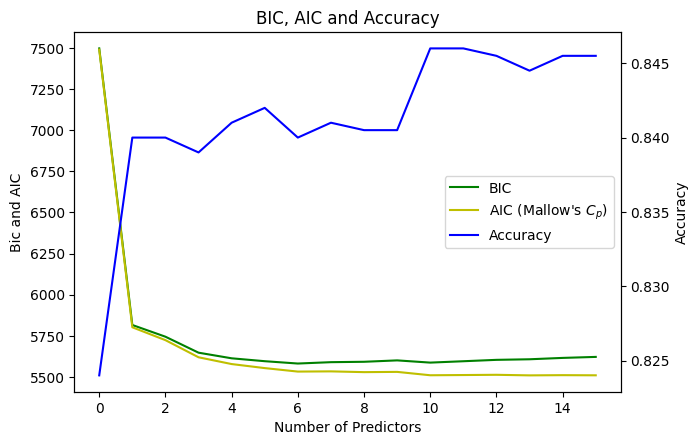

In [ ]:
fig, ax1 = plt.subplots(figsize=(7, 5))

fig.tight_layout(pad=4.0)

ax2 = ax1.twinx()
BicPlot, = ax1.plot(bic, 'g-', label = "BIC")
AicPlot, = ax1.plot(aic, 'y-', label = "AIC (Mallow's $C_p$)")
AccuracyPlot, = ax2.plot(AccuracyTestData, 'b-', label="Accuracy")

plt.legend([BicPlot, AicPlot, AccuracyPlot], ['BIC', 'AIC (Mallow\'s $C_p$)', 'Accuracy'], loc = 'center right')

ax1.set_xlabel('Number of Predictors')
ax1.set_ylabel('Bic and AIC')
ax2.set_ylabel('Accuracy')
plt.title("BIC, AIC and Accuracy")
plt.savefig(PathToRepo + '\\Plots\\BicAicAccuracy.png')

In [ ]:
print(bic.idxmin()) #Finds where minimum  and maximum values are
print(aic.idxmin())
print(AccuracyTestData.idxmax())

6
13
10


In [ ]:
model = models_best['model'].iloc[6]
summary = model.summary()
 
# Display and interpret results
with open(PathToRepo + '\\Tables\\GLMbestsubset.tex', 'w') as f:
    f.write(summary.as_latex())

#accuracy
pred = model.predict(sm.add_constant(x_test[model.params.index[1:]]))
print(accuracy_score(y_test, pred > 0.5))

summary

0.84


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:          IsMigratorInt   No. Observations:                 7999
Model:                            GLM   Df Residuals:                     7992
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -2759.4
Date:                Fri, 13 Dec 2024   Deviance:                       5518.8
Time:                        23:19:57   Pearson chi2:                 7.64e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.2181
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -1.4938      1.158     -1.290      0.197      -3.764       0.776
Rcyl           0.3973      0.017     22.913      0.000       0.363       0.431
vphi           0.0031      0.000      8.748      0.000       0.002       0.004
age           -0.4263      0.056     -7.599      0.000      -0.536      -0.316
ch            -2.0312      0.296     -6.871      0.000      -2.611      -1.452
ofe          -15.1186      3.155     -4.792      0.000     -21.302      -8.935
mgfe          28.7878      3.397      8.475      0.000      22.131      35.445
==============================================================================
"""